# Prediction Oil Temperature with ETTh1 dataset

### Import

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

### Read dataset

In [2]:
# Đọc dữ liệu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv("ETTm1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

target_col = 'OT'

data = df.values

### MSE Loss

In [3]:
def mse_loss(y_pred,y_true):
    return np.mean((y_pred-y_true)**2)

### Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69680 entries, 2016-07-01 00:00:00 to 2018-06-26 19:45:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    69680 non-null  float64
 1   HULL    69680 non-null  float64
 2   MUFL    69680 non-null  float64
 3   MULL    69680 non-null  float64
 4   LUFL    69680 non-null  float64
 5   LULL    69680 non-null  float64
 6   OT      69680 non-null  float64
dtypes: float64(7)
memory usage: 4.3 MB


In [5]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


### Thông số

In [6]:
n = len(df)

train_size = int(n * 0.6)
val_size   = int(n * 0.2)
test_size = int(n * 0.2)
print(f'Train size:{train_size}')
lr = 1e-4
weight_decay = 1e-4
drop_out = 0.3

seq_len = 336
pred_len = 24

hidden_size = 128
num_layer = 2
epochs = 50

Train size:41808


### Histogram biến mục tiêu

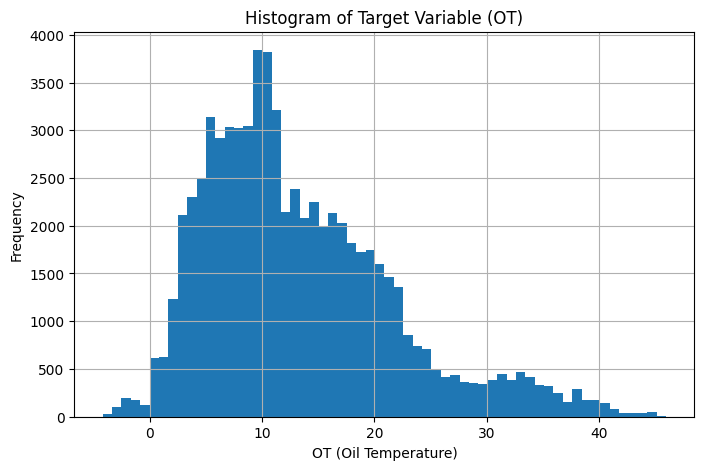

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["OT"], bins=60)
plt.title("Histogram of Target Variable (OT)")
plt.xlabel("OT (Oil Temperature)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Biểu đồ tương quan

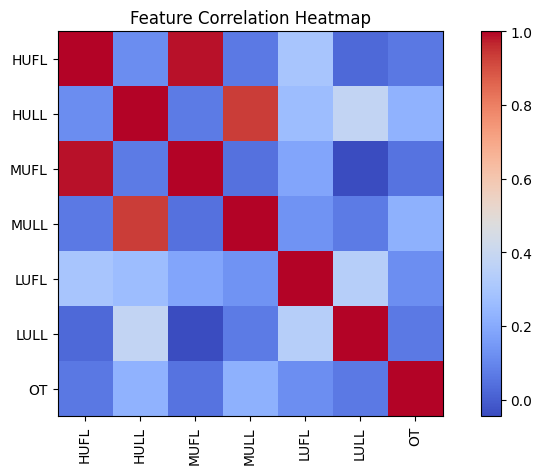

In [8]:
correlation = df.corr()
plt.figure(figsize=(10,5))
plt.imshow(correlation,cmap = 'coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns.tolist())), df.columns.tolist(), rotation=90)
plt.yticks(range(len(df.columns.tolist())), df.columns.tolist())

plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
# Drop cột MUFL MULL
df.drop(labels=['MUFL','MULL'],axis=1,inplace=True)

In [10]:
df.iloc[120:]

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-02 06:00:00,5.492,3.282,2.985,1.462,20.260000
2016-07-02 06:15:00,5.492,3.014,3.107,1.523,19.134001
2016-07-02 06:30:00,5.559,3.014,3.229,1.553,20.330000
2016-07-02 06:45:00,5.693,3.014,3.076,1.492,20.893000
2016-07-02 07:00:00,5.626,3.215,3.076,1.523,21.104000
...,...,...,...,...,...
2018-06-26 18:45:00,9.310,3.550,3.868,1.462,9.567000
2018-06-26 19:00:00,10.114,3.550,3.716,1.462,9.567000
2018-06-26 19:15:00,10.784,3.349,3.746,1.432,9.426000


### Data augment

In [11]:
stl = STL(df["OT"], period=24)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid

df["trend"] = trend
df["seasonal"] = seasonal
df["residual"] = residual



In [12]:
df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,24.742785,1.625535,4.162680
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,24.709245,1.440637,4.310118
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,24.675017,1.664924,3.698059
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,24.640090,0.660226,1.712685
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,24.604399,0.680168,2.502433


### Signal plot

plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(df["OT"])
plt.title("Original")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonal")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()
plt.show()

In [13]:
train_df = df.iloc[:train_size]
val_df   = df.iloc[train_size:train_size+val_size]
test_df  = df.iloc[train_size+val_size:]

In [14]:
train_df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,24.742785,1.625535,4.162680
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,24.709245,1.440637,4.310118
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,24.675017,1.664924,3.698059
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,24.640090,0.660226,1.712685
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,24.604399,0.680168,2.502433


### Timer Frezee

In [15]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-09-07 06:30:00,10.784,4.957,2.589,0.944,18.853001,19.217616,0.016692,-0.381308
2016-09-07 06:45:00,11.655,5.827,2.650,1.066,18.923000,19.333494,-0.101491,-0.309003
2016-09-07 07:00:00,10.315,5.827,2.467,1.127,19.063999,19.457956,-0.041346,-0.352611
2016-09-07 07:15:00,9.042,4.488,2.437,1.066,19.275000,19.591195,0.076377,-0.392572
2016-09-07 07:30:00,8.306,4.086,2.376,1.066,19.344999,19.733272,0.331343,-0.719616
2016-09-07 07:45:00,9.712,4.890,2.406,1.097,19.486000,19.884104,0.074834,-0.472937
2016-09-07 08:00:00,9.310,5.358,2.437,1.157,19.627001,20.043653,0.095286,-0.511937
2016-09-07 08:15:00,7.703,5.090,2.498,1.249,19.837999,20.212032,0.222403,-0.596436
2016-09-07 08:30:00,8.038,5.157,2.376,1.218,20.118999,20.389143,0.113354,-0.383497


In [16]:
# # tổng thay đổi mỗi dòng
# diff_sum_train = train_df.diff().abs().sum(axis=1)
# diff_sum_val = val_df.diff().abs().sum(axis=1)
# diff_sum_test = test_df.diff().abs().sum(axis=1)

# # dòng không thay đổi
# is_constant_train = diff_sum_train == 0
# is_constant_val = diff_sum_val == 0
# is_constant_test = diff_sum_test == 0

# # phát hiện block >= 6 giờ
# window = 6
# freeze_block_train = is_constant_train.rolling(window).sum() >= window
# freeze_block_val = is_constant_val.rolling(window).sum() >= window
# freeze_block_test = is_constant_test.rolling(window).sum() >= window

# train_df.loc[freeze_block_train] = np.nan
# val_df.loc[freeze_block_val] = np.nan
# test_df.loc[freeze_block_test] = np.nan

# train_df.interpolate(method="time", inplace=True)
# val_df.interpolate(method="time", inplace=True)
# test_df.interpolate(method="time", inplace=True)

In [17]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-09-07 06:30:00,10.784,4.957,2.589,0.944,18.853001,19.217616,0.016692,-0.381308
2016-09-07 06:45:00,11.655,5.827,2.650,1.066,18.923000,19.333494,-0.101491,-0.309003
2016-09-07 07:00:00,10.315,5.827,2.467,1.127,19.063999,19.457956,-0.041346,-0.352611
2016-09-07 07:15:00,9.042,4.488,2.437,1.066,19.275000,19.591195,0.076377,-0.392572
2016-09-07 07:30:00,8.306,4.086,2.376,1.066,19.344999,19.733272,0.331343,-0.719616
2016-09-07 07:45:00,9.712,4.890,2.406,1.097,19.486000,19.884104,0.074834,-0.472937
2016-09-07 08:00:00,9.310,5.358,2.437,1.157,19.627001,20.043653,0.095286,-0.511937
2016-09-07 08:15:00,7.703,5.090,2.498,1.249,19.837999,20.212032,0.222403,-0.596436
2016-09-07 08:30:00,8.038,5.157,2.376,1.218,20.118999,20.389143,0.113354,-0.383497


### Data Augment

In [18]:
def add_time_features(df):
    t = df.index.hour * 4 + df.index.minute // 15
    df["time_sin"] = np.sin(2*np.pi*t/96)
    df["time_cos"] = np.cos(2*np.pi*t/96)
    return df
train_df = add_time_features(train_df)
val_df = add_time_features(val_df)
test_df = add_time_features(test_df)

C:\Users\Admin\AppData\Local\Temp\ipykernel_27856\1165478958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_sin"] = np.sin(2*np.pi*t/96)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27856\1165478958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_cos"] = np.cos(2*np.pi*t/96)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27856\1165478958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [19]:
# #Train
# train_df["hour_sin"] = np.sin(2*np.pi*train_df.index.hour/24)
# train_df["hour_cos"] = np.cos(2*np.pi*train_df.index.hour/24)

# #Val
# val_df["hour_sin"] = np.sin(2*np.pi*val_df.index.hour/24)
# val_df["hour_cos"] = np.cos(2*np.pi*val_df.index.hour/24)

# #Test
# test_df["hour_sin"] = np.sin(2*np.pi*test_df.index.hour/24)
# test_df["hour_cos"] = np.cos(2*np.pi*test_df.index.hour/24)

In [20]:
df.head(10)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,24.742785,1.625535,4.162680
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,24.709245,1.440637,4.310118
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,24.675017,1.664924,3.698059
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,24.640090,0.660226,1.712685
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,24.604399,0.680168,2.502433
2016-07-01 01:15:00,5.492,1.942,4.112,1.279,27.716999,24.567836,1.019495,2.129668
2016-07-01 01:30:00,5.358,1.875,3.929,1.340,27.646000,24.530228,1.021553,2.094219
2016-07-01 01:45:00,5.157,1.808,3.807,1.279,27.084000,24.491324,1.098168,1.494508
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,24.450770,0.596032,2.740199


### Thống kê phân phối theo tập trước khi scale

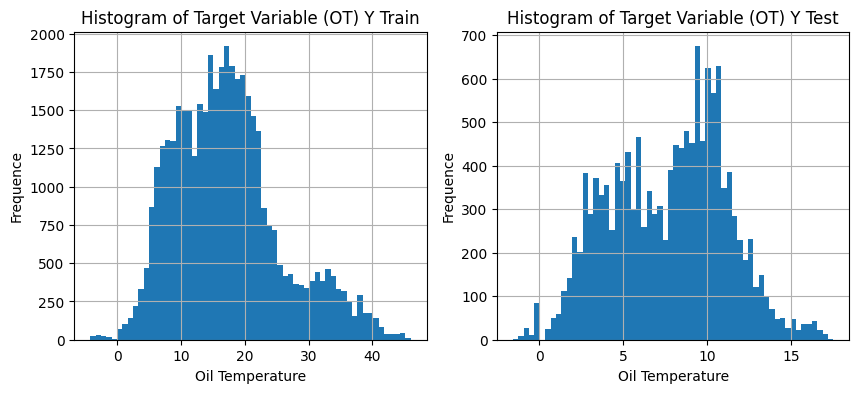

In [21]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([train_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Train')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.subplot(1,2,2)
plt.hist([test_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Test')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.show()

In [22]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

### Inverst Function

In [23]:
def inverst(x,scaler,target_index):
    return x * scaler.scale_[target_index] + scaler.mean_[target_index]

In [24]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, target_index):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_index = target_index

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len, self.target_index]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [25]:

# Targe Index
target_index = df.columns.get_loc(target_col)
print(target_index)
train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len, target_index)
val_dataset   = TimeSeriesDataset(val_scaled, seq_len, pred_len, target_index)
test_dataset  = TimeSeriesDataset(test_scaled, seq_len, pred_len, target_index)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

4


### Thống kê phân phối dữ liệu sau khi scale

In [26]:
y_train_all = []
y_test_all = []

for i in range(len(train_dataset)):
    _, y = train_dataset[i]
    y_train_all.append(y.numpy())

for i in range(len(test_dataset)):
    _, y = test_dataset[i]
    y_test_all.append(y.numpy())

y_train_all = np.concatenate(y_train_all)
y_test_all = np.concatenate(y_test_all)

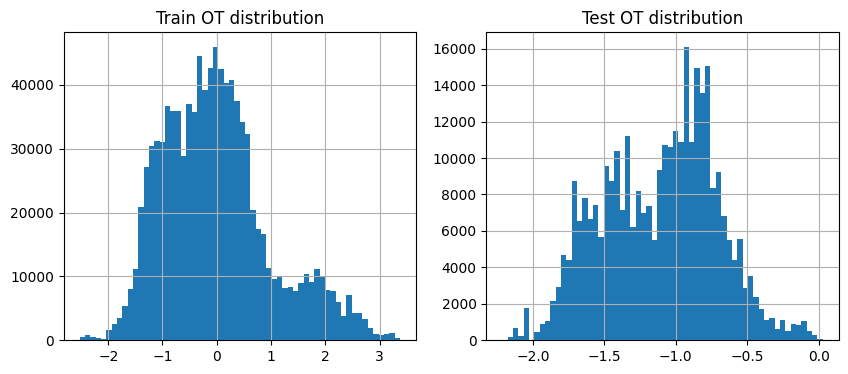

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(y_train_all, bins=60)
plt.title("Train OT distribution")
plt.grid(True)
plt.subplot(1,2,2)
plt.hist(y_test_all, bins=60)
plt.title("Test OT distribution")
plt.grid(True)
plt.show()

## Seq2SeqLSTM Model

In [28]:
# class Encoder(nn.Module):
#     def __init__(self, input_dim, hidden_size, num_layers, drop_out):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.num_layers = num_layers

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             dropout=drop_out,
#             batch_first=True,
#             bidirectional=True
#         )

#     def forward(self, x):
#         outputs, (hidden, cell) = self.lstm(x)

#         batch_size = x.size(0)

#         hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
#         cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)

#         hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)
#         cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)

#         return outputs, hidden, cell
# class Decoder(nn.Module):
#     def __init__(self, hidden_size, num_layers, drop_out):
#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_size=1,
#             hidden_size=hidden_size * 2,
#             num_layers=num_layers,
#             dropout=drop_out,
#             batch_first=True
#         )

#         self.fc = nn.Sequential(
#             nn.Linear(hidden_size * 2, 128),
#             nn.ReLU(),
#             nn.Dropout(drop_out),
#             nn.Linear(128, 1)
#         )

#     def forward(self, decoder_input, hidden, cell):
#         out, (hidden, cell) = self.lstm(decoder_input, (hidden, cell))
#         out = out.squeeze(1)
#         pred = self.fc(out)
#         return pred, hidden, cell

# class Seq2SeqLSTM(nn.Module):
#     def __init__(
#         self,
#         input_dim,
#         hidden_size=128,
#         num_layers=2,
#         pred_len=24,
#         drop_out=0.2,
#         teacher_forcing_ratio=0.2,
#         target_idx=0
#     ):
#         super().__init__()

#         self.encoder = Encoder(input_dim, hidden_size, num_layers, drop_out)
#         self.decoder = Decoder(hidden_size, num_layers, drop_out)

#         self.pred_len = pred_len
#         self.teacher_forcing_ratio = teacher_forcing_ratio
#         self.target_idx = target_idx

#     def forward(self, x, y=None):
#         batch_size = x.size(0)

#         _, hidden, cell = self.encoder(x)

#         decoder_input = x[:, -1:, self.target_idx:self.target_idx+1]

#         outputs = []

#         for t in range(self.pred_len):
#             pred, hidden, cell = self.decoder(decoder_input, hidden, cell)

#             outputs.append(pred.unsqueeze(1))

#             if self.training and y is not None and torch.rand(1).item() < self.teacher_forcing_ratio:
#                 if y.dim() == 2:
#                     decoder_input = y[:, t].unsqueeze(1).unsqueeze(2)
#                 else:
#                     decoder_input = y[:, t:t+1, :]
#             else:
#                 decoder_input = pred.unsqueeze(1)

#         outputs = torch.cat(outputs, dim=1)

#         return outputs.squeeze(-1)

In [29]:
import torch
import torch.nn as nn
import random

# ======================
# Encoder
# ======================
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, dropout):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        outputs, (hidden, cell) = self.lstm(x)

        # reshape hidden
        num_layers = hidden.shape[0] // 2
        batch = x.size(0)
        hidden_size = hidden.size(-1)

        hidden = hidden.view(num_layers, 2, batch, hidden_size)
        cell = cell.view(num_layers, 2, batch, hidden_size)

        hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)
        cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)

        return outputs, hidden, cell


# ======================
# Attention
# ======================
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.scale = 1.0 / (hidden_size ** 0.5)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden*2)
        # encoder_outputs: (batch, seq_len, hidden*2)

        hidden = hidden.unsqueeze(1)  # (batch, 1, hidden*2)

        attn = torch.bmm(hidden, encoder_outputs.transpose(1, 2))
        attn = torch.softmax(attn * self.scale, dim=-1)

        context = torch.bmm(attn, encoder_outputs)  # (batch, 1, hidden*2)

        return context.squeeze(1)


# ======================
# Decoder
# ======================
class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, dropout):
        super().__init__()

        self.attn = Attention(hidden_size * 2)

        self.lstm = nn.LSTM(
            input_size=input_dim + hidden_size * 2,
            hidden_size=hidden_size * 2,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, decoder_input, hidden, cell, encoder_outputs):
        # decoder_input: (batch, 1, input_dim)

        context = self.attn(hidden[-1], encoder_outputs)

        lstm_input = torch.cat([decoder_input.squeeze(1), context], dim=1)
        lstm_input = lstm_input.unsqueeze(1)

        out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        pred = self.fc(out.squeeze(1))

        return pred, hidden, cell


# ======================
# Seq2Seq
# ======================
class Seq2SeqLSTM(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size=128,
        num_layers=2,
        pred_len=24,
        dropout=0.2,
        target_idx=0
    ):
        super().__init__()

        self.encoder = Encoder(input_dim, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_dim, hidden_size, num_layers, dropout)

        self.pred_len = pred_len
        self.target_idx = target_idx

    def forward(self, x, y=None, teacher_forcing_ratio=0.5):
        batch_size = x.size(0)

        encoder_outputs, hidden, cell = self.encoder(x)

        decoder_input = x[:, -1:, :]  # FULL feature

        outputs = []

        for t in range(self.pred_len):
            pred, hidden, cell = self.decoder(
                decoder_input, hidden, cell, encoder_outputs
            )

            outputs.append(pred.unsqueeze(1))

            # Scheduled Sampling
            if self.training and y is not None:
                if random.random() < teacher_forcing_ratio:
                    next_input = y[:, t].unsqueeze(1).unsqueeze(2)
                else:
                    next_input = pred.unsqueeze(1)
            else:
                next_input = pred.unsqueeze(1)

            # concat lại full feature
            decoder_input = torch.cat([
                next_input,
                x[:, -1:, 1:]   # giữ feature khác
            ], dim=-1)

        outputs = torch.cat(outputs, dim=1)

        return outputs.squeeze(-1)


In [30]:
print(train_scaled.shape)

(41808, 10)


In [31]:
model = Seq2SeqLSTM(
    input_dim = train_scaled.shape[1],
    hidden_size = hidden_size,
    num_layers = num_layer,
    pred_len = pred_len,
    dropout = drop_out,
    target_idx = target_index
).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)


In [32]:
history = []
best_val_loss = float('inf')
train_loss = float('inf')
best_epoch = 0
patience = 5
counter = 0
for epoch in range(epochs):
    teacher_forcing_ratio = max(0.5 * (0.98 ** epoch), 0.05)
    model.train()
    total_train_loss = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = model(X_batch,y_batch,teacher_forcing_ratio = teacher_forcing_ratio)
        loss = criterion(output,y_batch)

        loss.backward() # Backpropagation Through Time

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

        optimizer.step() # Gradient Descent update
        y_train_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
        y_train_true = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)
        loss_real = mse_loss(y_train_pred,y_train_true)
        total_train_loss.append(loss_real)


    # ===== VALIDATION =====
    model.eval()
    total_val_loss = []

    with torch.no_grad():
        for X_val_batch,y_val_batch in val_loader:
            X_val_batch = X_val_batch.to(device)
            y_val_batch = y_val_batch.to(device)
            output = model(X_val_batch)
            y_val_true = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
            y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
            loss = mse_loss(y_val_pred,y_val_true)
            total_val_loss.append(loss)
    total_train_loss = np.average(total_train_loss)
    total_val_loss = np.average(total_val_loss)
    scheduler_reduce.step(total_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {total_train_loss:.4f} | "
        f"Val Loss: {total_val_loss:.4f} |"
        f"LR: {current_lr:.6f}"
    )
    # ===== SAVE BEST MODEL =====
    if total_val_loss < best_val_loss:
        train_loss = total_train_loss
        best_val_loss = total_val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': total_val_loss,
            'train_loss': total_train_loss,
            'lr':lr,
            'drop_out':drop_out,
            'seq_len':seq_len,
            'pred_len':pred_len
        }, "seq2seq_checkpoint.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break
    history.append((total_train_loss,total_val_loss))

Epoch 01 | Train Loss: 4.7585 | Val Loss: 1.5569 |LR: 0.000100
Epoch 02 | Train Loss: 1.5164 | Val Loss: 3.1347 |LR: 0.000100
Epoch 03 | Train Loss: 1.3152 | Val Loss: 0.5495 |LR: 0.000100
Epoch 04 | Train Loss: 1.2557 | Val Loss: 0.8592 |LR: 0.000100
Epoch 05 | Train Loss: 1.2162 | Val Loss: 1.0764 |LR: 0.000100
Epoch 06 | Train Loss: 1.1947 | Val Loss: 1.1566 |LR: 0.000100
Epoch 07 | Train Loss: 1.1624 | Val Loss: 0.7140 |LR: 0.000050
Epoch 08 | Train Loss: 1.1180 | Val Loss: 0.7117 |LR: 0.000050
Early stopping


In [33]:
print(f'Best Epoch:{best_epoch}')
print(f'Train Loss: {train_loss}')
print(f'Val Loss: {best_val_loss}')

Best Epoch:3
Train Loss: 1.3151993003842428
Val Loss: 0.5495119798899911


In [38]:
checkpoint = torch.load("seq2seq_checkpoint.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
total_loss=  []
preds = []
trues = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        output = model(x)
        y_val_true = inverst(y.detach().cpu().numpy(),scaler,target_index)
        y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
        loss = mse_loss(y_val_pred,y_val_true)
        total_loss.append(loss)
        preds.append(output.cpu().numpy())
        trues.append(y.cpu().numpy())
    total_loss = np.average(total_loss)
print(f'Loss: {total_loss}')
preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)



C:\Users\Admin\AppData\Local\Temp\ipykernel_27856\4228845488.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("seq2seq_checkpoint.pth", map_locati

Loss: 0.559812852064075


In [39]:
print(preds.shape)
print(trues.shape)

(13577, 24)
(13577, 24)


preds_flat = preds.reshape(-1,1)
trues_flat = trues.reshape(-1,1)

dummy_pred = np.zeros((preds_flat.shape[0], train_scaled.shape[1]))
dummy_true = np.zeros((trues_flat.shape[0], train_scaled.shape[1]))

dummy_pred[:, target_index] = preds_flat[:,0]
dummy_true[:, target_index] = trues_flat[:,0]

inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [40]:

# tạo mảng giả để inverse
dummy_pred = np.zeros((preds.shape[1], train_scaled.shape[1]))
dummy_true = np.zeros((trues.shape[1], train_scaled.shape[1]))

dummy_pred[:, target_index] = preds[0]
dummy_true[:, target_index] = trues[0]

inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [41]:
print(f'Prediction: {inv_pred}')
print(f'True: {inv_true}')
print(f'Real Loss: {MSE_Real}')

Prediction: [3.2690133  3.09670636 3.09575978 3.07429991 3.01872969 2.95455605
 2.90004097 2.86325117 2.84410348 2.84097053 2.85104101 2.87133515
 2.89884684 2.93285573 2.97170406 3.01394809 3.05946712 3.10715323
 3.15676598 3.20720762 3.25832496 3.31003683 3.36129316 3.41200264]
True: [3.09499987 3.44699971 3.65799975 3.51699995 3.58800053 3.09499987
 3.09499987 2.88399984 2.88399984 2.95500042 3.09499987 3.09499987
 3.02499964 3.23599968 3.51699995 3.79899955 3.58800053 3.72799998
 3.79899955 3.79899955 3.44699971 3.79899955 3.65799975 3.16599944]
Real Loss: 0.16848466798308834


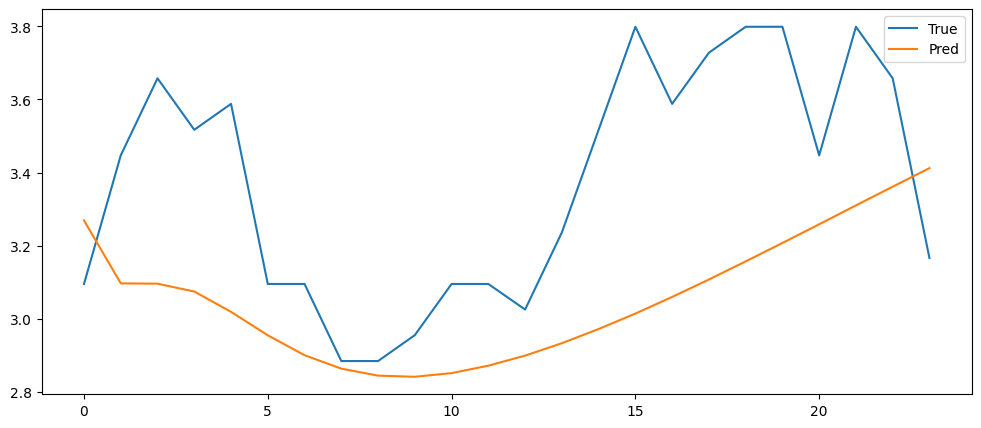

In [42]:
plt.figure(figsize=(12,5))
plt.plot(inv_true[:], label="True")
plt.plot(inv_pred[:], label="Pred")
plt.legend()
plt.show()

## Seq2SeqLSTM + Temporal Attention Model

In [43]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, H, h_t):
        h_t = h_t.unsqueeze(1).repeat(1, H.size(1), 1)

        score = torch.tanh(self.W1(H) + self.W2(h_t))

        # scale (quan trọng)
        score = self.V(score).squeeze(-1) / math.sqrt(H.size(-1))

        weights = torch.softmax(score, dim=1)

        context = torch.sum(weights.unsqueeze(-1) * H, dim=1)

        return context, weights


class LSTM_Attention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, horizon):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=drop_out   # regularization
        )

        self.attention = TemporalAttention(hidden_dim)
        # MLP head mạnh hơn
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Linear(hidden_dim, horizon)
        )
    def forward(self, x):
        H, (h_n, _) = self.lstm(x)

        h_t = h_n[-1]

        context, weights = self.attention(H, h_t)

        combined = torch.cat([h_t, context], dim=1)

        out = self.fc(combined)

        return out

In [44]:
attention_model = LSTM_Attention(
    input_dim = train_scaled.shape[1],
    hidden_dim = hidden_size,
    num_layers = num_layer,
    horizon = pred_len
).to(device)
atm_criterion = nn.MSELoss()
atm_optimizer = torch.optim.AdamW(attention_model.parameters(), lr=lr)
atm_scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
    atm_optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)
attention_history = []
attention_best_epoch = 0
attention_best_val_loss = float('inf')
attention_train_loss = float('inf')

### Train Fuction + Predict Function

In [45]:
def running_train(model, train_loader, val_loader, optimizer, criterion, scheduler_reduce, device, epochs, history, best_epoch, best_val_loss, train_loss,file):
    patience = 5
    counter = 0
    for epoch in range(epochs):

        model.train()
        total_train_loss = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)
            loss = criterion(output,y_batch)

            loss.backward() # Backpropagation Through Time

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

            optimizer.step() # Gradient Descent update
            y_train_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
            y_train_true = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)
            loss_real = mse_loss(y_train_pred,y_train_true)
            total_train_loss.append(loss_real)


        # ===== VALIDATION =====
        model.eval()
        total_val_loss = []

        with torch.no_grad():
            for X_val_batch,y_val_batch in val_loader:
                X_val_batch = X_val_batch.to(device)
                y_val_batch = y_val_batch.to(device)
                output = model(X_val_batch)
                y_val_true = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
                y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
                loss = mse_loss(y_val_pred,y_val_true)
                total_val_loss.append(loss)
        total_train_loss = np.average(total_train_loss)
        total_val_loss = np.average(total_val_loss)
        scheduler_reduce.step(total_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {total_train_loss:.4f} | "
            f"Val Loss: {total_val_loss:.4f} |"
            f"LR: {current_lr:.6f}"
        )
        # ===== SAVE BEST MODEL =====
        if total_val_loss < best_val_loss:
            train_loss = total_train_loss
            best_val_loss = total_val_loss
            best_epoch = epoch + 1
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': total_val_loss,
                'train_loss': total_train_loss,
                'lr':lr,
                'drop_out':drop_out,
                'seq_len':seq_len,
                'pred_len':pred_len
            }, file)
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping")
                break
        history.append((total_train_loss,total_val_loss))
    return best_epoch, best_val_loss, train_loss,history

In [46]:
def predict_running(model,data_loader,file):
  checkpoint = torch.load(file, map_location=device, weights_only=False)
  model.load_state_dict(checkpoint['model_state_dict'])
  model.eval()
  total_loss = []
  preds,trues = [],[]
  with torch.no_grad():
      for x, y in test_loader:
          x = x.to(device)
          y = y.to(device)
          output = model(x)
          y_val_true = inverst(y.detach().cpu().numpy(),scaler,target_index)
          y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
          loss = mse_loss(y_val_pred,y_val_true)
          total_loss.append(loss)
          preds.append(y_val_pred)
          trues.append(y_val_true)
      total_loss = np.average(total_loss)
  print(f'Loss: {total_loss}')
  preds = np.concatenate(preds, axis=0)
  trues = np.concatenate(trues, axis=0)
  print(f'Trues:{trues[0]}')
  print(f'Predict:{preds[0]}')
  return preds,trues,total_loss

### Train LSTM + Attention

In [47]:
attention_best_epoch,attention_best_val_loss,attention_train_loss,attention_history = running_train(
    attention_model,
    train_loader,
    val_loader,
    atm_optimizer,
    atm_criterion,
    atm_scheduler_reduce,
    device,
    epochs,
    attention_history,
    attention_best_epoch,
    attention_best_val_loss,
    attention_train_loss,
    'atm_checkpoint.pth'
)

Epoch 01 | Train Loss: 9.2189 | Val Loss: 1.7797 |LR: 0.000100
Epoch 02 | Train Loss: 3.0265 | Val Loss: 0.7230 |LR: 0.000100
Epoch 03 | Train Loss: 2.3625 | Val Loss: 1.4729 |LR: 0.000100
Epoch 04 | Train Loss: 2.0565 | Val Loss: 0.6969 |LR: 0.000100
Epoch 05 | Train Loss: 1.8937 | Val Loss: 0.7518 |LR: 0.000100
Epoch 06 | Train Loss: 1.7694 | Val Loss: 0.7113 |LR: 0.000100
Epoch 07 | Train Loss: 1.7113 | Val Loss: 0.6548 |LR: 0.000100
Epoch 08 | Train Loss: 1.6840 | Val Loss: 1.1697 |LR: 0.000100
Epoch 09 | Train Loss: 1.6342 | Val Loss: 0.5946 |LR: 0.000100
Epoch 10 | Train Loss: 1.5947 | Val Loss: 0.5845 |LR: 0.000100
Epoch 11 | Train Loss: 1.5581 | Val Loss: 0.6756 |LR: 0.000100
Epoch 12 | Train Loss: 1.5522 | Val Loss: 0.5813 |LR: 0.000100
Epoch 13 | Train Loss: 1.5363 | Val Loss: 0.8187 |LR: 0.000100
Epoch 14 | Train Loss: 1.5038 | Val Loss: 0.8584 |LR: 0.000100
Epoch 15 | Train Loss: 1.5294 | Val Loss: 0.5658 |LR: 0.000100
Epoch 16 | Train Loss: 1.5056 | Val Loss: 0.5749 |LR: 0

In [48]:
print(f'Best Epoch:{attention_best_epoch}')
print(f'Train Loss: {attention_train_loss}')
print(f'Val Loss: {attention_best_val_loss}')

Best Epoch:21
Train Loss: 1.420729083584087
Val Loss: 0.4884935207488899


### Predict LSTM + Attention Model

In [49]:
atm_preds,atm_trues,atm_total_loss = predict_running(attention_model,test_loader,'atm_checkpoint.pth')

Loss: 0.4365881168510176
Trues:[3.09499987 3.44699971 3.65799975 3.51699995 3.58800053 3.09499987
 3.09499987 2.88399984 2.88399984 2.95500042 3.09499987 3.09499987
 3.02499964 3.23599968 3.51699995 3.79899955 3.58800053 3.72799998
 3.79899955 3.79899955 3.44699971 3.79899955 3.65799975 3.16599944]
Predict:[3.73533826 3.71000685 3.68473226 3.59184265 3.56151253 3.50451788
 3.41789822 3.36570748 3.35714464 3.3437515  3.35651156 3.37457368
 3.39406937 3.40149388 3.51915385 3.56531103 3.65891691 3.75452349
 3.87610269 3.98416395 4.07766432 4.13981595 4.18065078 4.21167079]


### Plot Predict

In [50]:
def plot_function (preds,trues,total_loss,idx,criterion):
  MSE_Loss = criterion(torch.tensor(preds[idx]),torch.tensor(trues[idx]))
  print(f'Total Loss: {total_loss}')
  print(f'Sample {idx} Loss: {MSE_Loss}')
  plt.figure(figsize=(12,5))
  plt.plot(trues[idx], label="True")
  plt.plot(preds[idx], label="Pred")
  plt.title('Predict Plot')
  plt.legend()
  plt.show()

Total Loss: 0.4365881168510176
Sample 10 Loss: 0.8586534279374423


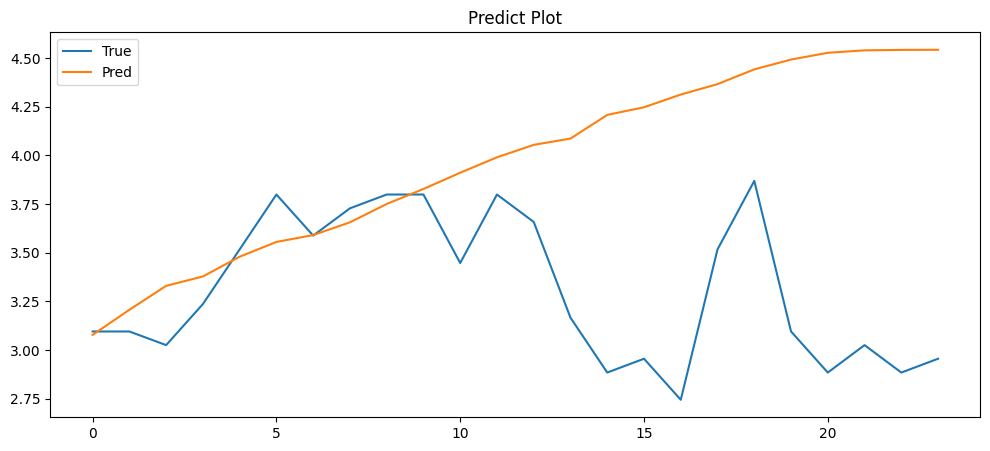

In [51]:
plot_function(atm_preds,atm_trues,atm_total_loss,10,atm_criterion)

## TCN Bilateral Model

In [52]:
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) \
            if in_channels != out_channels else None

    def forward(self, x):
        # x: (batch, channels, seq_len)

        out = self.conv1(x)
        out = out[:, :, :x.size(2)]  # causal cut
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = out[:, :, :x.size(2)]
        out = self.relu(out)
        out = self.dropout(out)

        res = x if self.downsample is None else self.downsample(x)

        return self.relu(out + res)
class TCN(nn.Module):
    def __init__(
        self,
        input_dim,
        num_channels,
        kernel_size=3,
        dropout=0.2,
        horizon=24
    ):
        super().__init__()

        layers = []
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation = 2 ** i

            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]

            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    dilation,
                    dropout
                )
            )

        self.network = nn.Sequential(*layers)

        self.fc = nn.Linear(num_channels[-1], horizon)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)

        x = x.permute(0, 2, 1)  # -> (batch, input_dim, seq_len)

        y = self.network(x)

        # lấy timestep cuối
        y = y[:, :, -1]

        out = self.fc(y)

        return out

In [53]:
TCN_model = TCN(
    input_dim=train_scaled.shape[1],
    num_channels=[64, 128, 128, 256],
    kernel_size=3,
    dropout=0.2,
    horizon=pred_len
).to(device)
TCN_criterion = nn.MSELoss()
TCN_optimizer = torch.optim.AdamW(TCN_model.parameters(),lr = lr)
TCN_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    TCN_optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)
TCN_history = []
TCN_best_epoch = 0
TCN_best_val_loss = float('inf')
TCN_best_train_loss = float('inf')

In [54]:
TCN_best_epoch,TCN_best_val_loss,TCN_best_train_loss,TCN_history = running_train(
  TCN_model,
  train_loader, val_loader,
  TCN_optimizer, TCN_criterion, TCN_scheduler,
  device,
  epochs,
  TCN_history, TCN_best_epoch, TCN_best_val_loss, TCN_best_train_loss,
  'TCN_checkpoint.pth'
)

Epoch 01 | Train Loss: 4.5127 | Val Loss: 0.7662 |LR: 0.000100
Epoch 02 | Train Loss: 1.2477 | Val Loss: 1.2186 |LR: 0.000100
Epoch 03 | Train Loss: 0.9726 | Val Loss: 0.8311 |LR: 0.000100
Epoch 04 | Train Loss: 0.8304 | Val Loss: 0.5923 |LR: 0.000100
Epoch 05 | Train Loss: 0.7379 | Val Loss: 0.5546 |LR: 0.000100
Epoch 06 | Train Loss: 0.6696 | Val Loss: 0.7126 |LR: 0.000100
Epoch 07 | Train Loss: 0.6226 | Val Loss: 0.5186 |LR: 0.000100
Epoch 08 | Train Loss: 0.5818 | Val Loss: 0.6157 |LR: 0.000100
Epoch 09 | Train Loss: 0.5451 | Val Loss: 0.4646 |LR: 0.000100
Epoch 10 | Train Loss: 0.5152 | Val Loss: 0.4018 |LR: 0.000100
Epoch 11 | Train Loss: 0.4889 | Val Loss: 0.5946 |LR: 0.000100
Epoch 12 | Train Loss: 0.4684 | Val Loss: 0.4199 |LR: 0.000100
Epoch 13 | Train Loss: 0.4516 | Val Loss: 0.6914 |LR: 0.000100
Epoch 14 | Train Loss: 0.4300 | Val Loss: 0.4262 |LR: 0.000050
Epoch 15 | Train Loss: 0.3955 | Val Loss: 0.5013 |LR: 0.000050
Early stopping


In [55]:
print(f'TCN Best Epoch: {TCN_best_epoch}')
print(f'TCN Train Loss: {TCN_best_train_loss}')
print(f'TCN Val Loss: {TCN_best_val_loss}')

TCN Best Epoch: 10
TCN Train Loss: 0.5152321997588905
TCN Val Loss: 0.40178211343941056


In [56]:
TCN_preds,TCN_trues,TCN_total_loss = predict_running(TCN_model,test_loader,'TCN_checkpoint.pth')

Loss: 0.42492417205230915
Trues:[3.09499987 3.44699971 3.65799975 3.51699995 3.58800053 3.09499987
 3.09499987 2.88399984 2.88399984 2.95500042 3.09499987 3.09499987
 3.02499964 3.23599968 3.51699995 3.79899955 3.58800053 3.72799998
 3.79899955 3.79899955 3.44699971 3.79899955 3.65799975 3.16599944]
Predict:[3.3408519  3.67288327 3.56984609 3.57121168 3.42597408 3.34735317
 3.48583485 3.22406648 3.20833885 3.12144222 2.97573488 3.32391594
 3.34468591 3.52969507 3.78715158 4.12600786 4.16847815 4.14284136
 4.27243148 4.39824948 4.18548107 3.89083808 3.85779098 3.93422857]


In [57]:
print(f'TCN Predict Loss: {TCN_total_loss}')
print(f'TCN Predict: {TCN_preds}')
print(f'TCN True Grouth: {TCN_trues}')

TCN Predict Loss: 0.42492417205230915
TCN Predict: [[ 3.3408519   3.67288327  3.56984609 ...  3.89083808  3.85779098
   3.93422857]
 [ 3.25901181  3.68132234  3.67101852 ...  3.95955795  3.91017449
   3.97019556]
 [ 3.47195472  3.71705902  3.58625753 ...  3.79338399  3.7480202
   3.73902617]
 ...
 [ 9.59080208  9.67271166  9.82251679 ...  9.02276189  9.02692512
   9.1120615 ]
 [ 9.86350329 10.03763135 10.29913035 ...  9.04626811  9.00271378
   9.179432  ]
 [10.17390282 10.3135208  10.45981151 ...  9.21731244  9.23980665
   9.37002122]]
TCN True Grouth: [[ 3.09499987  3.44699971  3.65799975 ...  3.79899955  3.65799975
   3.16599944]
 [ 3.44699971  3.65799975  3.51699995 ...  3.65799975  3.16599944
   2.88399984]
 [ 3.65799975  3.51699995  3.58800053 ...  3.16599944  2.88399984
   2.95500042]
 ...
 [ 9.70800042  9.98900018 10.19999971 ...  9.56700062  9.56700062
   9.4259998 ]
 [ 9.98900018 10.19999971 10.55200006 ...  9.56700062  9.4259998
   9.4259998 ]
 [10.19999971 10.55200006 10.692

Total Loss: 0.42492417205230915
Sample 100 Loss: 1.1076571988297195


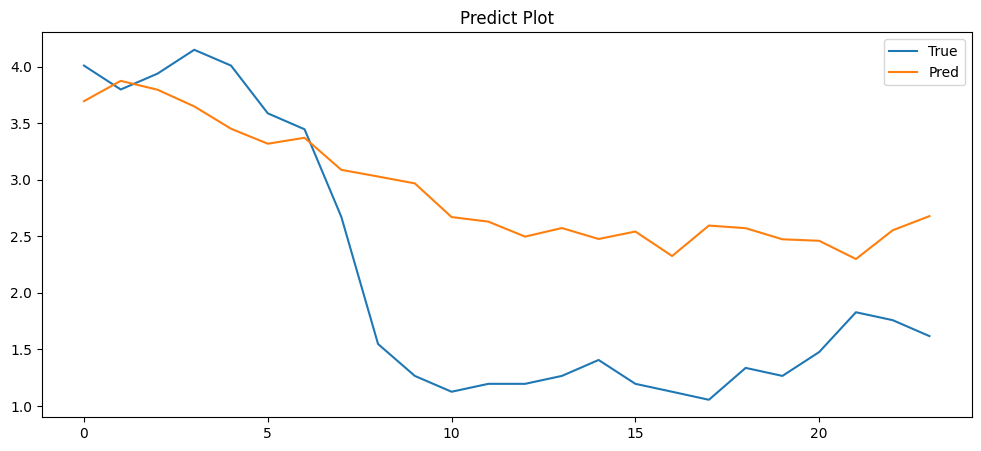

In [58]:
plot_function(TCN_preds,TCN_trues,TCN_total_loss,100,TCN_criterion)